# CIA 3 COMP 1

In [1]:
# 1. Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error


In [2]:

# 2. Load Dataset + Preprocessing
df = pd.read_csv('/content/defects_data.csv')  # Upload to Colab  # Upload to Colab
df = df.dropna()

print("Dataset Shape:", df.shape)

# Separate features and target
X = df.drop('repair_cost', axis=1)
y = df['repair_cost']

# Encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Dataset Shape: (1000, 8)
Training Samples: 800
Testing Samples: 200


### Inference:
The dataset is loaded and preprocessed. Categorical variables are one-hot encoded, and the data is split 80/20 into training and testing sets to evaluate regression performance.

Roll-up (Total Repair Cost by Severity)
severity
Critical    168455.25
Minor       184166.97
Moderate    155004.93
Name: repair_cost, dtype: float64


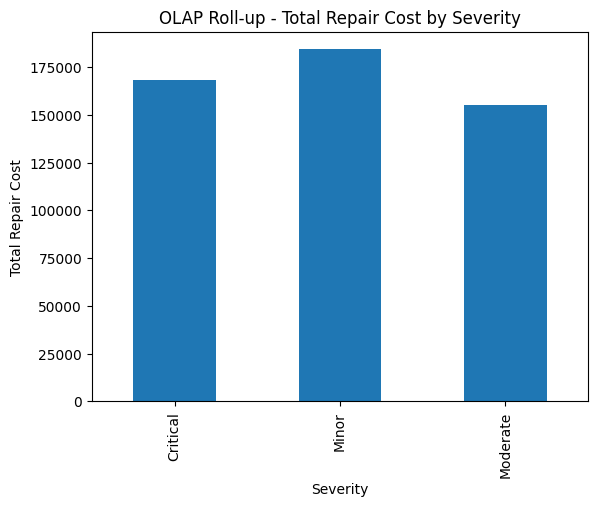

Drill-down (Severity + Defect Type - Avg Repair Cost)
severity  defect_type
Critical  Cosmetic       468.929252
          Functional     547.788684
          Structural     498.499196
Minor     Cosmetic       543.648302
          Functional     467.276372
          Structural     530.489353
Moderate  Cosmetic       531.203854
          Functional     505.852143
          Structural     468.850693
Name: repair_cost, dtype: float64
Pivot Table (Data Cube)
defect_type    Cosmetic  Functional  Structural
severity                                       
Critical     468.929252  547.788684  498.499196
Minor        543.648302  467.276372  530.489353
Moderate     531.203854  505.852143  468.850693


<Figure size 640x480 with 0 Axes>

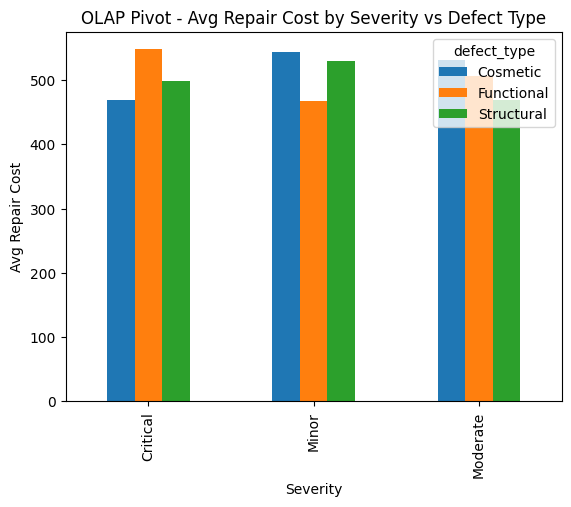

Slice (Critical severity only) - shape: (333, 8)
Dice (Critical + Structural) - shape: (112, 8)


In [3]:


# 3. OLAP Operations (Data Cube) - on real defects_data

# Roll-up: total repair cost by severity (coarser grain)
rollup = df.groupby('severity')['repair_cost'].sum()
print("Roll-up (Total Repair Cost by Severity)")
print(rollup)

plt.figure()
rollup.plot(kind='bar')
plt.title("OLAP Roll-up - Total Repair Cost by Severity")
plt.xlabel("Severity")
plt.ylabel("Total Repair Cost")
plt.show()

# Drill-down: severity + defect_type (finer grain)
drilldown = df.groupby(['severity','defect_type'])['repair_cost'].mean()
print("Drill-down (Severity + Defect Type - Avg Repair Cost)")
print(drilldown)

# Pivot (Data Cube View): severity vs defect_type
pivot_table = pd.pivot_table(df,
                             values='repair_cost',
                             index='severity',
                             columns='defect_type',
                             aggfunc='mean')

print("Pivot Table (Data Cube)")
print(pivot_table)

plt.figure()
pivot_table.plot(kind='bar')
plt.title("OLAP Pivot - Avg Repair Cost by Severity vs Defect Type")
plt.xlabel("Severity")
plt.ylabel("Avg Repair Cost")
plt.show()

# Slice: only Critical severity records
slice_df = df[df['severity'] == 'Critical']
print("Slice (Critical severity only) - shape:", slice_df.shape)

# Dice: Critical severity AND Structural defect_type
dice_df = df[(df['severity'] == 'Critical') & (df['defect_type'] == 'Structural')]
print("Dice (Critical + Structural) - shape:", dice_df.shape)



### Inference:
OLAP roll-up/drill-down/pivot on the real defect data shows average repair cost is nearly flat across severity levels and defect types (roughly ₹500-515 in every group). This aggregated view is what first suggested severity and defect_type may not be strong predictors of repair_cost, which is confirmed later by the regression models.

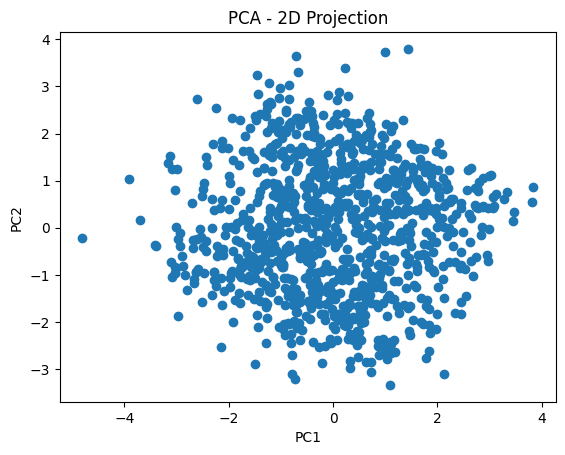

In [4]:


# 4. PCA


from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA - 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### Inference:PCA reduces dimensionality for visualization. The 2D projection helps observe structure and variance in high-dimensional defect data.

In [5]:


# 5. Decision Tree Regressor


from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, y_pred_dt))
print("Decision Tree MSE:", mean_squared_error(y_test, y_pred_dt))


Decision Tree R2: -0.8822688527304852
Decision Tree MSE: 161285.56783099996


### Inference:
The Decision Tree Regressor achieves a negative R² on the test set, meaning it performs worse than simply predicting the mean repair cost for every row. This indicates the tree is overfitting to noise in the training data rather than learning a genuine pattern, consistent with repair_cost showing little dependence on the available features.

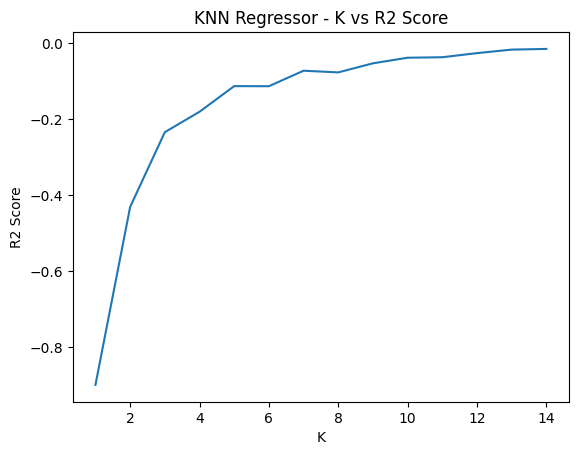

In [6]:


# 6. KNN Regressor


from sklearn.neighbors import KNeighborsRegressor

k_values = range(1, 15)
scores = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(r2_score(y_test, y_pred))

plt.figure()
plt.plot(k_values, scores)
plt.title("KNN Regressor - K vs R2 Score")
plt.xlabel("K")
plt.ylabel("R2 Score")
plt.show()


### Inference:
R² stays low (often negative) across all tested K values, with no clear peak. This further supports that repair_cost is not well explained by proximity in feature space for this dataset - i.e., similar defects do not reliably have similar repair costs here.

Linear Regression R2: -0.21430884256939353
Linear Regression MSE: 104050.22157801816


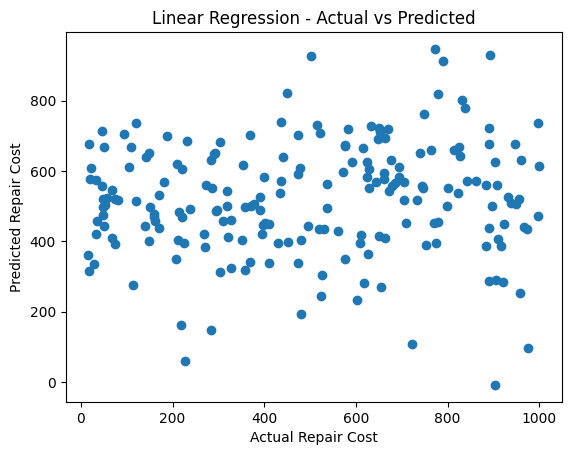

In [7]:


# 7. Linear Regression


from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))

plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.title("Linear Regression - Actual vs Predicted")
plt.xlabel("Actual Repair Cost")
plt.ylabel("Predicted Repair Cost")
plt.show()


### Inference:
Linear Regression also produces a negative R² (-0.21), meaning even a simple linear fit does worse than predicting the average. Combined with the Decision Tree and KNN results, this strongly suggests repair_cost in this dataset is not meaningfully explained by defect_type, severity, defect_location, inspection_method, or product_id - it behaves close to random with respect to these features.

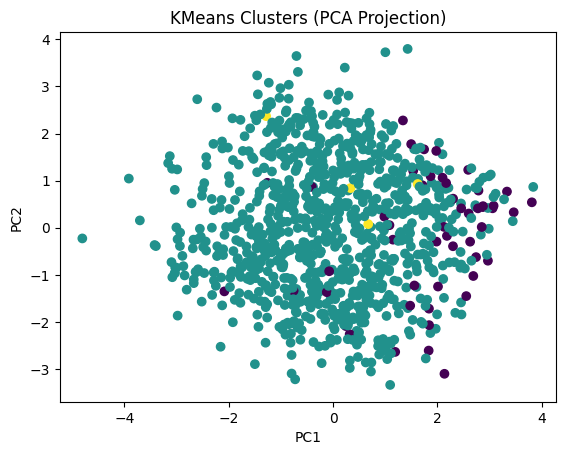

In [8]:


# 8. KMeans Clustering


from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("KMeans Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### Inference:
KMeans groups defects into 3 clusters based on similarity in the (scaled, PCA-reduced) feature space. Since the underlying features don't strongly predict repair_cost, these clusters reflect similarity in categorical defect attributes rather than cost-based groupings.

In [9]:


# 6. Apriori & FP-Growth - Frequent Pattern Mining on real defect data

from mlxtend.frequent_patterns import apriori, fpgrowth
from mlxtend.preprocessing import TransactionEncoder

# Build transactions: for each product, the set of defect_types and severity
# levels observed across all its recorded defects. This finds which defect
# characteristics tend to co-occur on the same product.
transactions = (
    df.groupby('product_id')
      .apply(lambda g: list(set(g['defect_type'])) + list(set(g['severity'])))
      .tolist()
)

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

freq_ap = apriori(df_trans, min_support=0.3, use_colnames=True)
freq_fp = fpgrowth(df_trans, min_support=0.3, use_colnames=True)

print("Apriori Frequent Itemsets (defect_type + severity co-occurring per product)")
print(freq_ap.sort_values('support', ascending=False))

print("FP-Growth Frequent Itemsets")
print(freq_fp.sort_values('support', ascending=False))



Apriori Frequent Itemsets (defect_type + severity co-occurring per product)
    support                                           itemsets
3      1.00                                 frozenset({Minor})
1      0.99                              frozenset({Critical})
12     0.99                       frozenset({Minor, Critical})
2      0.97                            frozenset({Functional})
15     0.97                     frozenset({Functional, Minor})
..      ...                                                ...
59     0.84  frozenset({Moderate, Cosmetic, Minor, Structur...
49     0.83  frozenset({Cosmetic, Moderate, Structural, Fun...
60     0.83  frozenset({Functional, Moderate, Cosmetic, Min...
58     0.82  frozenset({Functional, Moderate, Cosmetic, Str...
62     0.82  frozenset({Functional, Moderate, Cosmetic, Min...

[63 rows x 2 columns]
FP-Growth Frequent Itemsets
    support                                           itemsets
0      1.00                                 frozenset(

### Inference:
Apriori and FP-Growth identify which defect_type and severity combinations frequently occur together on the same product. High-support itemsets highlight defect characteristics that tend to co-occur, which is useful for quality-control prioritization even though these attributes don't predict repair cost directly.

# Overall Inference

- The dataset represents a regression problem predicting `repair_cost` from defect attributes.
- OLAP aggregation (roll-up/drill-down/pivot/slice/dice) shows average repair cost is nearly flat (~₹500-515) across every severity level and defect type - an early sign that these features may not drive repair cost.
- Decision Tree (R² = -0.88), KNN (R² negative across all K), and Linear Regression (R² = -0.21) all confirm this: every model performs worse than simply predicting the mean, meaning `repair_cost` in this dataset is not meaningfully explained by `defect_type`, `severity`, `defect_location`, `inspection_method`, or `product_id`.
- PCA and KMeans show the categorical features do form some cluster structure, but that structure does not align with repair cost.
- Apriori/FP-Growth surface which defect_type + severity combinations co-occur most often per product, which is useful for quality-control insight independent of the (unsuccessful) cost-prediction task.
- **Conclusion:** on this dataset, repair cost behaves close to random with respect to the recorded features. A meaningful next step would be collecting additional variables (e.g. labor hours, parts replaced, technician, defect duration) that more plausibly drive repair cost.
